# Results Dashboard — Phase 2

One consolidated view of the project's results: equity curves, bootstrapped Sharpe confidence intervals, and per-asset out-of-sample metrics. Everything on this page is measured on the **held-out test window** (the last 20% of history the model never trained on).

**The story in one line:** the ML strategy shows no statistically significant risk-adjusted edge and no ability to predict next-day direction on any asset.

In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_auc_score, f1_score

from backtest import run_backtest
from load import show_ticker_list

tickers = show_ticker_list()
more_liquid = ["SPY", "QQQ", "AAPL", "MSFT", "NVDA"]

strategies = {
    "Buy & Hold": "buy_and_hold",
    "Benchmark 20%": "benchmark 20",
    "Logistic (ML)": "simple logistic",
    "SMA 20/50": "sma",
    "12-1": "12-1",
}

# Run every strategy on every ticker once, over the test window.
curves = {}
for ticker in tickers:
    for label, key in strategies.items():
        curve, dates = run_backtest(ticker, key)
        curves[(ticker, label)] = (curve, dates)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 1. Equity curves (test window)

The ML strategy against the baselines and passive buy-and-hold, per ticker.

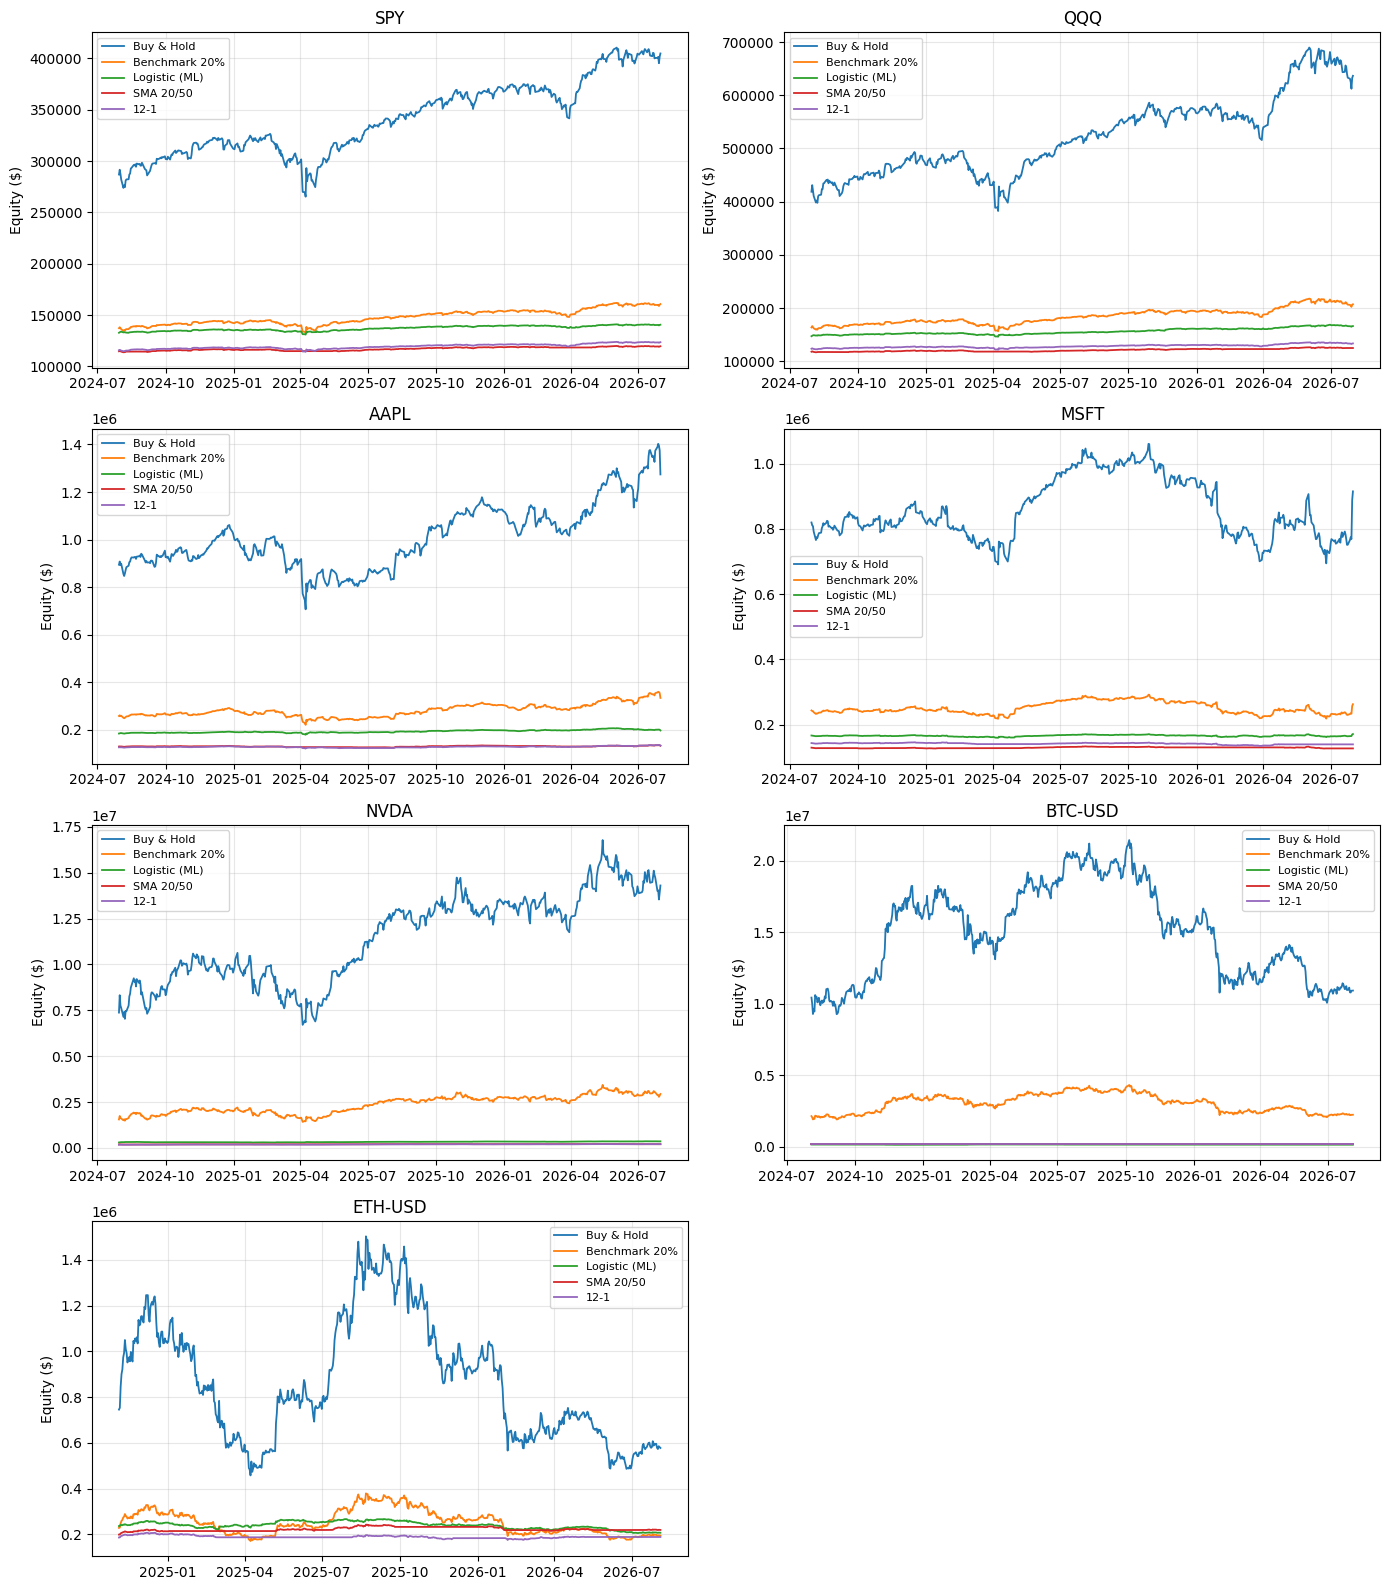

In [2]:
n = len(tickers)
rows = (n + 1) // 2
fig, axes = plt.subplots(rows, 2, figsize=(14, 4 * rows))
axes = axes.flatten()

for ax, ticker in zip(axes, tickers):
    for label in strategies:
        curve, dates = curves[(ticker, label)]
        ax.plot(dates, curve, label=label, linewidth=1.3)
    ax.set_title(ticker)
    ax.set_ylabel("Equity ($)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## 2. Bootstrapped Sharpe confidence intervals

The single most important chart. For each ticker, the ML strategy's point Sharpe (dot) with its 95% bootstrap confidence interval (bar). **Every interval crossing the zero line means the Sharpe is not statistically distinguishable from zero** — i.e., no significant risk-adjusted edge.

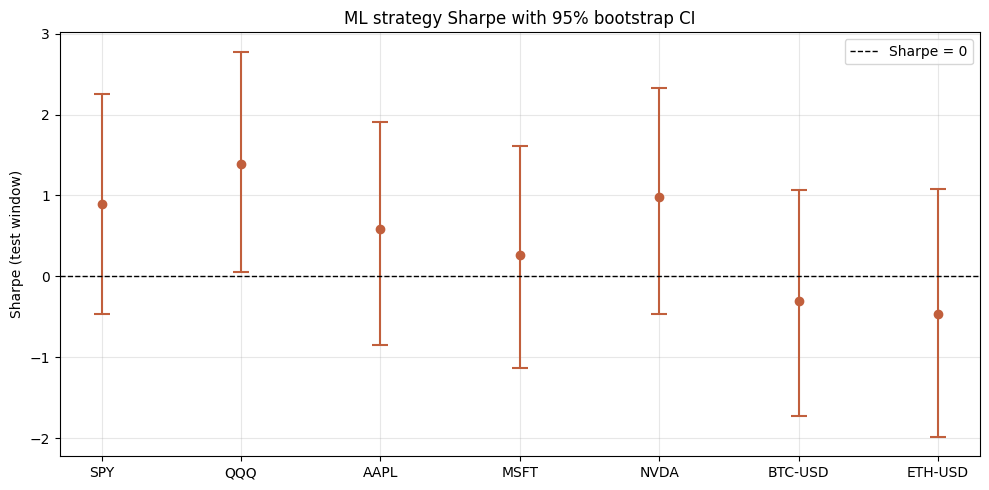

,ticker,sharpe,ci_low,ci_high
0,SPY,0.888,-0.464,2.257
1,QQQ,1.389,0.050,2.777
2,AAPL,0.579,-0.852,1.910
3,MSFT,0.261,-1.134,1.607
4,NVDA,0.979,-0.470,2.327
5,BTC-USD,-0.305,-1.720,1.068
6,ETH-USD,-0.467,-1.985,1.080


In [3]:
def calculate_sharpe(returns, period):
    r = np.array(returns, dtype=float)
    return (r.mean() / r.std()) * np.sqrt(period)

records = []
for ticker in tickers:
    curve, dates = curves[(ticker, "Logistic (ML)")]
    rewards = [(curve[i] - curve[i - 1]) / curve[i - 1] * 100 for i in range(1, len(curve))]
    period = 252 if ticker in more_liquid else 365

    point = calculate_sharpe(rewards, period)
    boot = [calculate_sharpe(np.random.choice(rewards, size=len(rewards), replace=True), period)
            for _ in range(2000)]
    low, high = np.percentile(boot, [2.5, 97.5])
    records.append({"ticker": ticker, "sharpe": point, "ci_low": low, "ci_high": high})

sharpe_df = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(10, 5))
yerr = [sharpe_df["sharpe"] - sharpe_df["ci_low"], sharpe_df["ci_high"] - sharpe_df["sharpe"]]
ax.errorbar(sharpe_df["ticker"], sharpe_df["sharpe"], yerr=yerr,
            fmt="o", capsize=6, capthick=1.5, elinewidth=1.5, color="#c15f3c")
ax.axhline(0, color="black", linewidth=1, linestyle="--", label="Sharpe = 0")
ax.set_ylabel("Sharpe (test window)")
ax.set_title("ML strategy Sharpe with 95% bootstrap CI")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

sharpe_df.round(3)

Every confidence interval includes 0 (and each is enormously wide, ~2.7 Sharpe units) — with only ~500 test-window days, the Sharpe cannot be distinguished from noise on any ticker. The QQQ/NVDA point Sharpes that looked good in the raw backtest are **not statistically significant.**

## 3. Per-asset out-of-sample metrics

Does the model generalize across assets? Accuracy vs. each ticker's own base rate, plus AUC (ranking ability). Evaluated on each ticker's own test slice.

In [4]:
model = joblib.load("models/logistic_model.pkl")
scaler = joblib.load("models/scaler.pkl")

rows = []
for ticker in tickers:
    df = pd.read_parquet(f"data/processed/{ticker}.parquet")
    df = df.iloc[int(len(df) * 0.8):]          # test slice: last 20%
    X = df.iloc[:, :18]
    y = df.iloc[:, -1]
    Xs = scaler.transform(X)

    rows.append({
        "ticker": ticker,
        "base_rate": y.mean(),
        "accuracy": model.score(Xs, y),
        "auc": roc_auc_score(y, model.predict_proba(Xs)[:, 1]),
    })

gen_df = pd.DataFrame(rows)
gen_df["edge_over_base"] = gen_df["accuracy"] - gen_df["base_rate"]
gen_df.round(3)

,ticker,base_rate,accuracy,auc,edge_over_base
0,SPY,0.568,0.562,0.502,-0.006
1,QQQ,0.576,0.574,0.543,-0.002
2,AAPL,0.542,0.534,0.495,-0.008
3,MSFT,0.523,0.507,0.535,-0.016
4,NVDA,0.536,0.515,0.538,-0.020
5,BTC-USD,0.498,0.498,0.507,0.000
6,ETH-USD,0.503,0.502,0.500,-0.002


Accuracy sits **at or below the base rate on every ticker**, and **AUC ≈ 0.50** everywhere — the model has no discriminative ability on any asset. The failure is universal, not asset-specific.

## Conclusion

Across all three views — equity curves, Sharpe confidence intervals, and per-asset classification metrics — the verdict is consistent:

- The ML strategy earns **less than passive buy-and-hold** on returns and its Sharpe is **not statistically distinguishable from zero** on any ticker.
- Out of sample it sits **at the base rate** with **AUC ≈ 0.50** on every asset — no ability to predict next-day direction.

Combined with the model-family comparison (logistic / RF / XGBoost all at base rate) and the walk-forward robustness check, this is a **rigorous, honest negative result**: next-day direction on these liquid assets is effectively unpredictable from price/volume-derived features.